# Social Personas

Does giving Player 2 a social persona change the outcome of self-play negotiation? Following Bianchi et al. (NegotiationArena, §2), Player 1 keeps the default behaviour while Player 2 is assigned one of three personas: **default** (none), **desperate** (feign desperation and beg), or **cunning** (manipulate the opponent and insult them). Every game is **self-play** — both seats are the same model — so the measured persona effect is an interaction effect. It combines how the model negotiates when carrying the persona as P2 with how the same model, in the default P1 seat, reacts to begging or insults from its counterpart. It is therefore not a pure measure of P2 persuasion skill.

The `default` condition already carries P1's structural seat advantage, so the effect of a persona is read as the change *from* `default`, not as a raw P2-vs-P1 score.

Per game and tier: 3 model families $\times$ 3 personas $\times$ 30 games = 90 runs per persona, 270 per cell. Three tiers (4–9B / 12–14B / 24–27B) and two parse-retry conditions (`no_retries`, `retry3`).

### Metrics

| Metric | Why it is reported |
|---|---|
| **Completion rate** | Prerequisite, and a direct test of whether the hostile/begging text itself breaks the protocol. Separates *format* failure (repaired by `retry3`) from *negotiation* breakdown. |
| **P2 win rate** (ties excluded, Wilson 95% CI) | The headline interaction metric: does the persona-bearing P2 beat its identical default-seat counterpart more often? Read as the gap above the `default` bar. |
| **P2 average payoff** (native units, bootstrap 95% CI) | What P2 actually keeps. Diverges from win rate when a persona wins decided games but collapses others to 0. |
| **No-deal rate** (Wilson 95% CI) | The mechanism: tests whether the persona interaction destroys value (a rejected game scores 0 for both). |

### Bianchi et al. reference points
- **Trading:** both personas raised P2's win rate and payoff.
- **BuySell:** the buyer (P2) already wins (price settles below the midpoint); personas slightly raised payoff.
- **Ultimatum:** personas had a large effect — without one the responder rarely beat the proposer; cunning raised P2's win rate to 82% but barely improved payoff, because the hostility broke deals (the "risk of cunning").

In [1]:
import sys, os, json, warnings
from pathlib import Path
import matplotlib.patches as mpatches


def find_repo_root():
    starts = []
    seen = set()

    def add_start(path_like):
        if not path_like:
            return
        try:
            path = Path(path_like).resolve()
        except (FileNotFoundError, OSError, RuntimeError):
            return
        key = str(path)
        if key not in seen:
            seen.add(key)
            starts.append(path)

    if "__file__" in globals():
        add_start(Path(__file__).resolve().parent)

    try:
        add_start(Path.cwd())
    except (FileNotFoundError, OSError, RuntimeError):
        pass

    add_start(os.environ.get("PWD"))
    for start in starts:
        for candidate in (start, *start.parents):
            if ((candidate / ".logs").exists()
                    and (candidate / "configs").exists()
                    and (candidate / "_notebooks").exists()):
                return candidate
    raise FileNotFoundError("Could not find repository root containing .logs, configs, and _notebooks")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "_notebooks" / "oss" / "style"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

# Publication design system (_notebooks/oss/style): sans-serif report skin,
# colorblind palette, value-axis gridlines, and constrained layout.
import style
style.apply_thesis_style()
FULL_WIDTH, HALF_WIDTH = style.FULL_WIDTH, style.HALF_WIDTH

LOGS_ROOT = str(ROOT_DIR / ".logs")
SIZES = ["very_small", "small", "medium"]
NOTEBOOK_NAME = "2_persona_analysis"
FIG_DIR = ROOT_DIR / "_notebooks" / "oss" / "figures" / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, slug):
    """Save figures WITHOUT the descriptive title -- the LaTeX \caption supplies it.
    Panel/facet titles (game, tier) are kept; only the whole-figure title is hidden.
    """
    hidden = []
    sup = getattr(fig, "_suptitle", None)
    if sup is not None and sup.get_text():
        sup.set_visible(False); hidden.append(sup)
    real_axes = [a for a in fig.axes if a.get_label() != "<colorbar>"]
    if len(real_axes) == 1 and real_axes[0].get_title():
        t = real_axes[0].title
        t.set_visible(False); hidden.append(t)
    path = FIG_DIR / f"{slug}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    for artist in hidden:
        artist.set_visible(True)
    return path

<>:68: SyntaxWarning: invalid escape sequence '\c'
<>:68: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_32849/2225838197.py:68: SyntaxWarning: invalid escape sequence '\c'
  """Save figures WITHOUT the descriptive title -- the LaTeX \caption supplies it.


In [2]:
def clean_name(full_id):
    name = full_id.split("/")[-1]
    for suffix in ["-Instruct", "-instruct"]:
        name = name.replace(suffix, "")
    return name

def resource_value(res):
    return sum(res["_value"].values())

def model_family(name):
    low = name.lower()
    if low.startswith("gemma"): return "Gemma"
    if low.startswith(("ministral", "mistral")): return "Mistral"
    if low.startswith("qwen"): return "Qwen"
    return "Other"

In [3]:
import re
from scipy import stats as sps
from style import wilson_ci, bootstrap_ci, errbars_from_ci

GAMES = {"Trading": "trading", "Ultimatum": "ultimatum", "BuySell": "buysell"}
CONDITIONS = ["retry3", "no_retries"]
FAMILIES = ["Gemma", "Mistral", "Qwen"]
PERSONAS = ["default", "desperate", "cunning"]
PERSONA_LABEL = {"default": "Default", "desperate": "Desperate", "cunning": "Cunning"}
SIZE_LABELS = style.SIZE_LABEL

persona_pal = style.PERSONA_COLORS                                  # default/desperate/cunning
fam_pal = {f: style.FAMILY_COLORS[f.lower()] for f in FAMILIES}
cond_pal = {"no_retries": "#9AA0A6", "retry3": "#0173B2"}
PHASE_TEXT = "#3D3C38"
# feasible payoff ranges (as in the cross-play benchmark); BuySell surplus with price in [0,100]
PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "BuySell": (-40, 60)}
# even-outcome reference per game: zero-sum parity / even split / equal 10-ZUP surplus split
NEUTRAL = {"Trading": 0, "Ultimatum": 50, "BuySell": 10}
PAYOFF_AXIS = {"Trading": "Mean payoff", "Ultimatum": "Mean payoff", "BuySell": "Mean payoff"}
_PERSONA_RE = re.compile(r"_(default|desperate|cunning)(?:/|$)")


def _persona_from_path(path):
    m = _PERSONA_RE.search(path)
    return m.group(1) if m else None


def _load_run(path, game):
    with open(path) as f:
        data = json.load(f)
    states = data["game_state"]
    last = states[-1]
    players = data["players"]
    # Completed only if it reached END *and* wrote a summary: a few BuySell runs
    # reach END with no summary block, i.e. no valid terminal state was recorded.
    completed = last.get("current_iteration") == "END" and "summary" in last
    turn_states = [s for s in states if s.get("current_iteration") not in ("START", "END")]
    settings = states[0].get("settings", {})
    behaviours = settings.get("player_social_behaviour", ["", ""])
    persona = _persona_from_path(path)
    if persona is None:                                             # fall back to the prompt text
        b2 = behaviours[1] if len(behaviours) > 1 else ""
        persona = "default" if not b2 else ("cunning" if "cunning" in b2 else "desperate")
    row = dict(
        model=clean_name(players[0].get("model_id", players[0].get("model", "?"))),
        persona=persona, completed=completed, num_turns=len(turn_states),
        payoff_1=np.nan, payoff_2=np.nan, deal=False, final_response=None, path=path,
    )
    if not completed:
        return row
    s = last["summary"]
    row["final_response"] = str(s.get("final_response"))
    row["deal"] = row["final_response"] == "ACCEPT"
    if game == "Trading":
        init, fin = s["initial_resources"], s["final_resources"]
        p1 = resource_value(fin[0]) - resource_value(init[0])
        p2 = resource_value(fin[1]) - resource_value(init[1])
    elif game == "Ultimatum":
        p1 = resource_value(s["player_outcome"][0])
        p2 = resource_value(s["player_outcome"][1])
    else:  # BuySell: P1 = seller (cost 40), P2 = buyer (value 60); player_outcome = surplus
        o1, o2 = s["player_outcome"]
        try:
            p1, p2 = float(o1), float(o2)
        except (TypeError, ValueError):
            p1 = p2 = np.nan
    if not row["deal"]:                                             # no deal -> both score 0
        p1 = p2 = 0.0
    row["payoff_1"], row["payoff_2"] = p1, p2
    return row


_rows = []
for _game, _prefix in GAMES.items():
    for _cond in CONDITIONS:
        _suffix = "_retry3" if _cond == "retry3" else ""
        for _size in SIZES:
            _dir = os.path.join(LOGS_ROOT, f"section_two/{_prefix}_section_two_personas{_suffix}/{_size}")
            for _root, _dirs, _files in os.walk(_dir):
                if "game_state.json" not in _files:
                    continue
                try:
                    r = _load_run(os.path.join(_root, "game_state.json"), _game)
                except Exception:
                    continue
                r.update(game=_game, condition=_cond, size=_size)
                _rows.append(r)

MASTER = pd.DataFrame(_rows)
MASTER["family"] = MASTER["model"].map(model_family)
MASTER["persona"] = pd.Categorical(MASTER["persona"], PERSONAS, ordered=True)
_lo = MASTER["game"].map(lambda g: PAYOFF_BOUNDS[g][0])
_hi = MASTER["game"].map(lambda g: PAYOFF_BOUNDS[g][1])
MASTER["payoff_valid"] = MASTER["payoff_1"].between(_lo, _hi) & MASTER["payoff_2"].between(_lo, _hi)
MASTER["no_deal"] = MASTER["completed"] & ~MASTER["deal"]


def _winner(r):
    if not r.completed:
        return "incomplete"
    if not r.payoff_valid or not np.isfinite(r.payoff_1):
        return "invalid"
    if r.payoff_1 > r.payoff_2: return "P1"
    if r.payoff_2 > r.payoff_1: return "P2"
    return "tie"


MASTER["winner"] = MASTER.apply(_winner, axis=1)
# P2 carries the persona. win_2 = 1 if P2 wins, 0 if P1 wins, NaN for ties/no-deals (excluded).
MASTER["win_2"] = np.where(MASTER["winner"].isin(["P1", "P2"]),
                           (MASTER["winner"] == "P2").astype(float), np.nan)

RETRY3 = MASTER[MASTER["condition"] == "retry3"].copy()
NORETRY = MASTER[MASTER["condition"] == "no_retries"].copy()


def winrate(df, by):
    """Ties-excluded P2 win rate per group, with Wilson 95% CIs."""
    d = df[df["win_2"].notna()]
    t = d.groupby(by, observed=True)["win_2"].agg(k="sum", n="count").reset_index()
    t["rate"] = t["k"] / t["n"]
    t[["lo", "hi"]] = t.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)
    return t


def rate_table(df, col, by):
    """Generic proportion (e.g. completed, no_deal) per group, with Wilson 95% CIs."""
    t = df.groupby(by, observed=True)[col].agg(k="sum", n="count").reset_index()
    t["rate"] = t["k"] / t["n"]
    t[["lo", "hi"]] = t.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)
    return t


def payoff(df, by, col="payoff_2"):
    """Mean P2 payoff per group over payoff-valid completed games, bootstrap 95% CIs."""
    keys = by if isinstance(by, list) else [by]
    pv = df[df["completed"] & df["payoff_valid"]]
    out = []
    for key, sub in pv.groupby(keys, observed=True):
        vals = sub[col].to_numpy(dtype=float)
        lo, hi = bootstrap_ci(vals)
        rec = dict(zip(keys, key if isinstance(key, tuple) else (key,)))
        rec.update(mean=float(np.nanmean(vals)), lo=lo, hi=hi, n=len(vals))
        out.append(rec)
    return pd.DataFrame(out)


print(MASTER.groupby(["game", "condition"]).size().unstack())
print("\nretry3 completion by game:",
      RETRY3.groupby("game")["completed"].mean().round(3).to_dict())
print("payoff-invalid completed games:", int((MASTER.completed & ~MASTER.payoff_valid).sum()))

condition  no_retries  retry3
game                         
BuySell           810     810
Trading           810     813
Ultimatum         810     810

retry3 completion by game: {'BuySell': 0.983, 'Trading': 0.913, 'Ultimatum': 0.979}
payoff-invalid completed games: 13


## Phase 1 — Open Exploration

The retry3 persona runs are first inspected at several levels: pooled game/persona summaries, model-level deltas against each model's own default condition, family/tier averages, and transcript-derived first moves. This section records which patterns deserve formal analysis and where the evidence is thin.

In [4]:
# Open exploration: compact summaries before committing to formal comparisons.
# Why these summaries are informative: they expose where persona changes coincide with fewer
# completed/decided games, so later win-rate differences are not mistaken for unconditional gains.
explore_summary = []
for g in GAMES:
    for p in PERSONAS:
        sub = RETRY3[(RETRY3["game"] == g) & (RETRY3["persona"] == p)]
        dec = sub[sub["win_2"].notna()]
        pv = sub[sub["completed"] & sub["payoff_valid"]]
        comp = sub[sub["completed"]]
        explore_summary.append(dict(
            game=g, persona=p, runs=len(sub), completed=sub["completed"].mean(),
            decided=len(dec), p2_win_rate=dec["win_2"].mean(),
            p2_payoff=pv["payoff_2"].mean(), no_deal=comp["no_deal"].mean()))
explore_summary = pd.DataFrame(explore_summary)
display(explore_summary.round({"completed": 3, "p2_win_rate": 3, "p2_payoff": 2, "no_deal": 3}))

# Model-level effects against each model's default condition.
# Why: a pooled mean can hide opposite persona effects across models.
model_effect = winrate(RETRY3, ["game", "model", "family", "size", "persona"]).pivot_table(
    index=["game", "model", "family", "size"], columns="persona", values=["rate", "n"], observed=True)
open_rows = []
for idx, row in model_effect.iterrows():
    for p in ["desperate", "cunning"]:
        open_rows.append(dict(
            game=idx[0], model=idx[1], family=idx[2], size=idx[3], persona=p,
            default_win=row[("rate", "default")], persona_win=row[("rate", p)],
            delta_win=row[("rate", p)] - row[("rate", "default")],
            default_decided=row[("n", "default")], persona_decided=row[("n", p)]))
OPEN_EFFECT = pd.DataFrame(open_rows)
print("Largest absolute win-rate changes vs each model's default condition:")
display(OPEN_EFFECT.assign(abs_delta=lambda d: d["delta_win"].abs())
        .sort_values("abs_delta", ascending=False)
        .drop(columns="abs_delta")
        .head(12)
        .round({"default_win": 3, "persona_win": 3, "delta_win": 3}))

print("Mean win-rate change by family:")
display(OPEN_EFFECT.groupby(["game", "persona", "family"], observed=True)["delta_win"]
        .mean().unstack("family").reindex(columns=FAMILIES).round(3))

print("Mean win-rate change by tier:")
display(OPEN_EFFECT.groupby(["game", "persona", "size"], observed=True)["delta_win"]
        .mean().unstack("size").reindex(columns=SIZES).round(3))

,game,persona,runs,completed,decided,p2_win_rate,p2_payoff,no_deal
0,Trading,default,270,0.937,184,0.766,2.89,0.020
1,Trading,desperate,270,0.919,184,0.641,2.28,0.060
2,Trading,cunning,273,0.883,178,0.719,3.77,0.133
3,Ultimatum,default,270,0.981,168,0.143,26.19,0.132
4,Ultimatum,desperate,270,0.978,178,0.230,28.54,0.121
5,Ultimatum,cunning,270,0.978,61,0.705,16.48,0.727
6,BuySell,default,270,0.978,206,0.752,14.03,0.011
7,BuySell,desperate,270,0.985,180,0.967,15.06,0.293
8,BuySell,cunning,270,0.985,148,0.851,12.31,0.402


Largest absolute win-rate changes vs each model's default condition:


,game,model,family,size,persona,default_win,persona_win,delta_win,default_decided,persona_decided
26,Trading,Qwen3.5-27B,Qwen,medium,desperate,1.000,0.000,-1.000,9.0,3.0
51,Ultimatum,gemma-3-27b-it,Gemma,medium,cunning,0.095,1.000,0.905,21.0,6.0
45,Ultimatum,Qwen3.5-27B,Qwen,medium,cunning,0.150,0.947,0.797,20.0,19.0
47,Ultimatum,Qwen3.5-9B,Qwen,very_small,cunning,0.087,0.800,0.713,23.0,10.0
7,BuySell,Qwen3-14B,Qwen,small,cunning,0.931,0.250,-0.681,29.0,12.0
14,BuySell,gemma-3-27b-it,Gemma,medium,desperate,0.308,0.964,0.657,26.0,28.0
15,BuySell,gemma-3-27b-it,Gemma,medium,cunning,0.308,0.958,0.651,26.0,24.0
49,Ultimatum,gemma-3-12b-it,Gemma,small,cunning,0.000,0.625,0.625,30.0,8.0
2,BuySell,Ministral-3-8B-2512,Mistral,very_small,desperate,0.400,0.950,0.550,20.0,20.0
44,Ultimatum,Qwen3.5-27B,Qwen,medium,desperate,0.150,0.667,0.517,20.0,27.0


Mean win-rate change by family:


family               Gemma  Mistral   Qwen
game      persona                         
BuySell   cunning    0.146    0.277 -0.284
          desperate  0.231    0.350  0.046
Trading   cunning   -0.114   -0.058  0.052
          desperate -0.126   -0.078 -0.333
Ultimatum cunning    0.489   -0.046  0.448
          desperate  0.047    0.078  0.135

Mean win-rate change by tier:


size                 very_small  small  medium
game      persona                             
BuySell   cunning        -0.089 -0.139   0.366
          desperate       0.183  0.089   0.355
Trading   cunning        -0.322  0.066   0.136
          desperate      -0.174  0.090  -0.453
Ultimatum cunning         0.060  0.231   0.601
          desperate       0.003 -0.024   0.281

The exploration points to three formal questions. First, the persona effect is uneven: the largest cells are model-specific swings, not small perturbations around one common effect. Second, baseline position matters descriptively: the biggest positive shifts often occur where default P2 was weak, but the relation is not strong enough to treat as an explanation on its own. Third, win rate and payoff split apart when personas increase no-deals. This is clearest for cunning in Ultimatum and BuySell, where fewer games reach a value-preserving agreement. Because the experiment is self-play, these patterns describe both sides of the interaction: persona-conditioned P2 behavior and same-model P1 response.

## Phase 2 —  Analysis

## 1. Does a persona help P2 win? (retry3)

Win rate is over completed, payoff-valid games with a decisive winner; ties (including every
no-deal, where both sides score 0) are excluded. This is therefore a *conditional* metric: it
measures who wins **given that the game reaches a decisive outcome**, not how often it does. That
caveat matters here because the personas move the no-deal rate (§4): under cunning the denominator
shrinks to the minority of games that reach a deal, so its win rate must be read together with
payoff (§2) and the no-deal rate (§3). Each bar is annotated with its decided-game count $n$. The
dashed line marks parity (0.5). Because P1 is the same model on default behaviour, the `default` bar
is the seat baseline and the persona's effect is the gap above (or below) it.

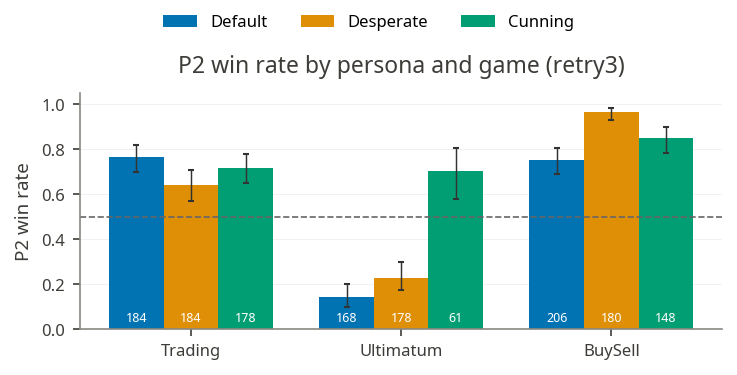

persona    default  desperate  cunning
game                                  
BuySell      0.752      0.967    0.851
Trading      0.766      0.641    0.719
Ultimatum    0.143      0.230    0.705


In [5]:
#  P2 win rate by persona and game (retry3)
t = winrate(RETRY3, ["game", "persona"])
games = list(GAMES); x = np.arange(len(games)); width = 0.26
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.8, 2.4))
for i, p in enumerate(PERSONAS):
    sub = t[t["persona"] == p].set_index("game").reindex(games)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["rate"], width, label=PERSONA_LABEL[p], color=persona_pal[p])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    for xi, nv in zip(pos, sub["n"].values):       # decided-game count: the win-rate denominator
        if np.isfinite(nv):
            ax.text(xi, 0.02, f"{int(nv)}", ha="center", va="bottom", fontsize=6, color="white")
ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
ax.set_xticks(x, games); ax.set_ylabel("P2 win rate"); ax.set_ylim(0, 1.05)
ax.set_title("P2 win rate by persona and game (retry3)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=3, frameon=False)
save_plot(fig, "winrate_by_persona_game")
plt.show()
print(t.pivot_table(index="game", columns="persona", values="rate", observed=True)
      .reindex(columns=PERSONAS).round(3).to_string())

The persona effect is largest where the default P2 position is weakest, but the pattern is game-specific.

In **Ultimatum**, the default responder wins only 0.14 of decided games and **cunning** raises that rate to 0.71, the largest pooled win-rate change in the notebook. In **BuySell**, the buyer already has a strong default win rate (0.75), and **desperate** raises it to 0.97. **Trading does not replicate the original persona gain**: desperate lowers P2's decided-game win rate from 0.77 to 0.64, and cunning is close to default. Cunning's Ultimatum bar also rests on far fewer decided games than the default bar, so the win-rate gain must be read together with payoff and no-deal rates.

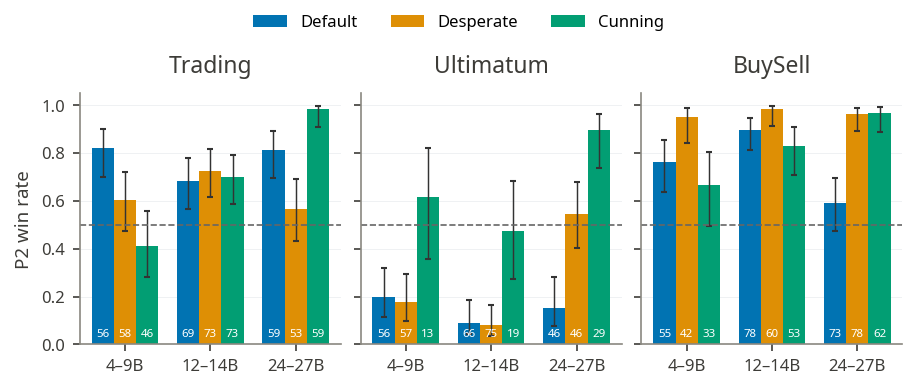

In [6]:
#  P2 win rate by persona and tier, faceted by game (retry3)
t = winrate(RETRY3, ["game", "size", "persona"])
x = np.arange(len(SIZES)); width = 0.26
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.5), sharey=True)
for ax, g in zip(axes, GAMES):
    for i, p in enumerate(PERSONAS):
        sub = (t[(t["game"] == g) & (t["persona"] == p)]
               .set_index("size").reindex(SIZES))
        pos = x + (i - 1) * width
        ax.bar(pos, sub["rate"], width, label=PERSONA_LABEL[p], color=persona_pal[p])
        ax.errorbar(pos, sub["rate"],
                    yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
        for xi, nv in zip(pos, sub["n"].values):   # decided-game count per cell (small once split)
            if np.isfinite(nv):
                ax.text(xi, 0.02, f"{int(nv)}", ha="center", va="bottom", fontsize=5.5, color="white")
    ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
    ax.set_xticks(x, [SIZE_LABELS[s] for s in SIZES]); ax.set_title(g); ax.set_ylim(0, 1.05)
axes[0].set_ylabel("P2 win rate")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside upper center", ncols=3, frameon=False)
save_plot(fig, "winrate_by_persona_tier")
plt.show()

Cunning's Ultimatum gain is largest at the **medium** tier (0.90) and weaker below it (0.47 at
small, 0.62 at very-small). The per-bar samples are small once split this way
(e.g. the small-tier cunning Ultimatum cell has only 19 decided games), so the intervals are wide
and the non-monotonicity across tiers should not be over-read. Trading shows no consistent
ordering by tier for any persona.

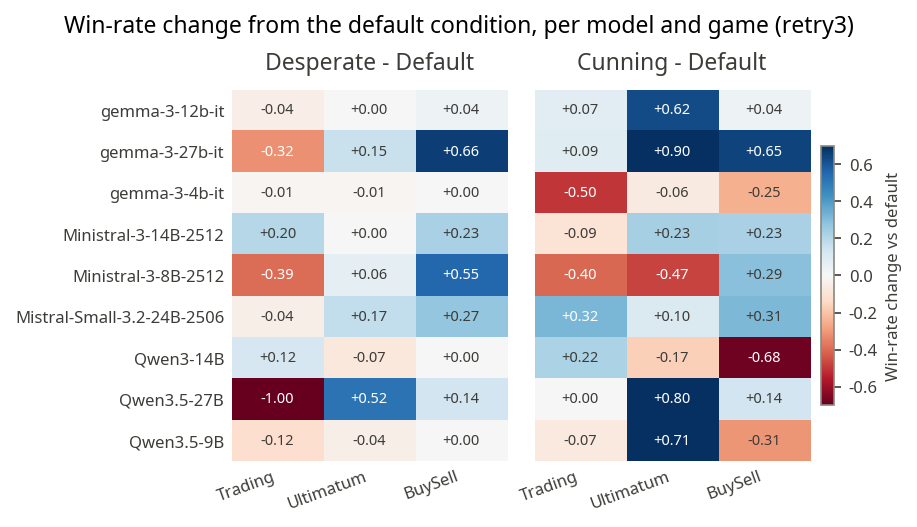

In [7]:
#  Win-rate change vs default, per model x game (retry3, pooled over tiers)
wr = winrate(RETRY3, ["game", "model", "persona"]).pivot_table(
    index=["game", "model"], columns="persona", values="rate", observed=True)
delta = wr[["desperate", "cunning"]].sub(wr["default"], axis=0)
models = sorted(RETRY3["model"].unique(),
                key=lambda m: (FAMILIES.index(model_family(m)), m))

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.4), sharey=True)
V = 0.7
for ax, p in zip(axes, ["desperate", "cunning"]):
    mat = np.array([[delta.loc[(g, m), p] if (g, m) in delta.index else np.nan
                     for g in GAMES] for m in models], dtype=float)
    im = ax.imshow(np.ma.masked_invalid(mat), cmap="RdBu", vmin=-V, vmax=V, aspect="auto")
    ax.set_xticks(range(len(GAMES)), list(GAMES), rotation=20, ha="right")
    ax.set_yticks(range(len(models)), models)
    ax.grid(False); ax.spines[:].set_visible(False); ax.tick_params(length=0)
    ax.set_title(f"{PERSONA_LABEL[p]} - Default")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if np.isnan(mat[i, j]):
                continue
            ax.text(j, i, f"{mat[i, j]:+.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(mat[i, j]) > 0.45 * V else PHASE_TEXT)
cb = fig.colorbar(im, ax=axes, shrink=0.7, pad=0.02)
cb.set_label("Win-rate change vs default", fontsize=8)
fig.suptitle("Win-rate change from the default condition, per model and game (retry3)")
save_plot(fig, "winrate_delta_heatmap")
plt.show()

Read row by row, the persona effect is uneven across models (blue = the persona raised
P2's win rate, red = lowered it). Cunning's Ultimatum gains are large for several models
(gemma-3-27b +0.90, Qwen3.5-27B +0.80, Qwen3.5-9B +0.71, gemma-3-12b +0.62) but absent or negative
for the weakest (gemma-3-4b −0.06, Ministral-8B −0.47). In Trading the cells are small and mixed in
sign, consistent with no real effect. The single largest loss is Qwen3-14B in BuySell, where
cunning collapses its buyer win rate by 0.68.

## 2. Payoff

Win rate counts decided games; it says nothing about what P2 keeps. Payoff is in native units
(Trading net resources, Ultimatum dollars, BuySell surplus) with 95% bootstrap CIs. No-deals
contribute their 0 here, so a persona that wins more often but breaks more deals can raise win rate
while lowering payoff.

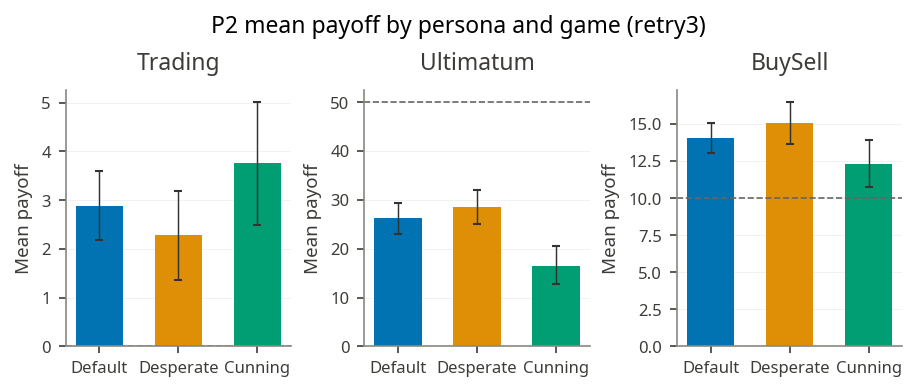

Trading {'default': 2.89, 'desperate': 2.28, 'cunning': 3.77}
Ultimatum {'default': 26.19, 'desperate': 28.54, 'cunning': 16.48}
BuySell {'default': 14.03, 'desperate': 15.06, 'cunning': 12.31}


In [8]:
#  P2 mean payoff by persona, faceted by game (retry3, native units)
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.5))
for ax, g in zip(axes, GAMES):
    t = payoff(RETRY3[RETRY3["game"] == g], ["persona"]).set_index("persona").reindex(PERSONAS)
    x = np.arange(len(PERSONAS))
    ax.bar(x, t["mean"], 0.6, color=[persona_pal[p] for p in PERSONAS])
    yerr = np.vstack([(t["mean"] - t["lo"]).clip(lower=0).values,
                      (t["hi"] - t["mean"]).clip(lower=0).values])
    ax.errorbar(x, t["mean"], yerr=yerr, fmt="none", ecolor="0.2", lw=0.7, capsize=2)
    ax.axhline(NEUTRAL[g], ls="--", lw=0.8, color="0.4")
    ax.set_xticks(x, [PERSONA_LABEL[p] for p in PERSONAS])
    ax.set_title(g); ax.set_ylabel(PAYOFF_AXIS[g])
fig.suptitle("P2 mean payoff by persona and game (retry3)")
save_plot(fig, "payoff_by_persona_game")
plt.show()
for g in GAMES:
    t = payoff(RETRY3[RETRY3["game"] == g], ["persona"]).set_index("persona").reindex(PERSONAS)
    print(g, {p: round(t.loc[p, "mean"], 2) for p in PERSONAS})

 In **Ultimatum** cunning wins the most decided games yet returns the **lowest** payoff — 16.5 dollars against the default's 26.2 — because most cunning games end in
a destroyed pot. **Desperate** instead lifts both win rate and payoff (28.5). The same split holds
in **BuySell**: desperate raises buyer surplus (15.1 vs 14.0) while cunning lowers it (12.3).
Trading payoffs are small and their intervals overlap, so no persona claim is supported there.

### Conditional payoff among accepted Ultimatum deals

Mean payoff over all valid games is the expected payoff metric: no-deals remain in the denominator and score 0. Accepted-deal payoff is informative as a diagnostic because it separates how often a persona reaches agreement from how favorable the agreement is once it happens.

,deal_rate,accepted_deals,decisive_deals,tied_deals,p2_payoff_all_valid_games,p2_payoff_in_accepted_deals
persona,,,,,,
default,0.867,228,168.0,60.0,26.194,30.215
desperate,0.879,232,178.0,54.0,28.538,32.474
cunning,0.267,70,61.0,9.0,16.481,61.686


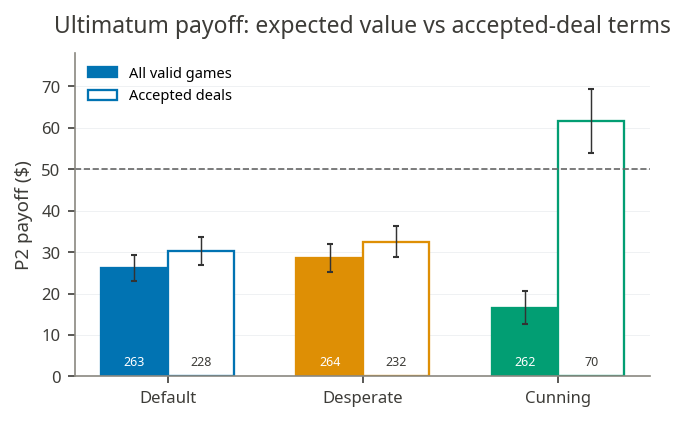

In [9]:
#  Ultimatum payoff conditional on accepted deals (retry3).
# Why: this separates expected payoff from the terms obtained in the minority of games that reach agreement.
ult = RETRY3[(RETRY3["game"] == "Ultimatum") & RETRY3["completed"] & RETRY3["payoff_valid"]].copy()
rows = []
for p in PERSONAS:
    sub = ult[ult["persona"] == p]
    deals = sub[sub["deal"]]
    decisive_deals = deals[deals["payoff_1"] != deals["payoff_2"]]
    for label, frame in [("All valid games", sub), ("Accepted deals", deals)]:
        vals = frame["payoff_2"].to_numpy(dtype=float)
        lo, hi = bootstrap_ci(vals) if len(vals) else (np.nan, np.nan)
        rows.append(dict(persona=p, metric=label, n=len(vals), mean=np.nanmean(vals), lo=lo, hi=hi))
    rows[-1].update(deal_rate=len(deals) / len(sub), decisive_deals=len(decisive_deals), tied_deals=len(deals) - len(decisive_deals))
ult_payoff_cond = pd.DataFrame(rows)
summary = (ult_payoff_cond[ult_payoff_cond["metric"] == "Accepted deals"]
           .set_index("persona")[["n", "deal_rate", "mean", "decisive_deals", "tied_deals"]]
           .rename(columns={"n": "accepted_deals", "mean": "p2_payoff_in_accepted_deals"})
           .reindex(PERSONAS))
summary["p2_payoff_all_valid_games"] = (ult_payoff_cond[ult_payoff_cond["metric"] == "All valid games"]
                                         .set_index("persona")["mean"].reindex(PERSONAS))
display(summary[["deal_rate", "accepted_deals", "decisive_deals", "tied_deals",
                 "p2_payoff_all_valid_games", "p2_payoff_in_accepted_deals"]].round(3))

fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.72, 2.7))
x = np.arange(len(PERSONAS)); width = 0.34
for j, metric in enumerate(["All valid games", "Accepted deals"]):
    sub = ult_payoff_cond[ult_payoff_cond["metric"] == metric].set_index("persona").reindex(PERSONAS)
    pos = x + (j - 0.5) * width
    colors = [persona_pal[p] if metric == "All valid games" else "white" for p in PERSONAS]
    edges = [persona_pal[p] for p in PERSONAS]
    ax.bar(pos, sub["mean"], width, label=metric, color=colors, edgecolor=edges, linewidth=1.1)
    yerr = np.vstack([(sub["mean"] - sub["lo"]).clip(lower=0).values,
                      (sub["hi"] - sub["mean"]).clip(lower=0).values])
    ax.errorbar(pos, sub["mean"], yerr=yerr, fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    for xi, nv in zip(pos, sub["n"].values):
        ax.text(xi, 2, f"{int(nv)}", ha="center", va="bottom", fontsize=6,
                color="white" if metric == "All valid games" else PHASE_TEXT)
ax.axhline(50, ls="--", lw=0.8, color="0.4")
ax.set_xticks(x, [PERSONA_LABEL[p] for p in PERSONAS])
ax.set_ylabel("P2 payoff ($)")
ax.set_ylim(0, 78)
ax.set_title("Ultimatum payoff: expected value vs accepted-deal terms")
ax.legend(frameon=False, fontsize=7, loc="upper left")
save_plot(fig, "ultimatum_payoff_conditional_deals")
plt.show()

Cunning has the clearest split between frequency and terms. It reaches accepted deals in only about a quarter of valid Ultimatum games, so its expected payoff is the lowest of the three personas. Conditional on an accepted deal, however, P2 keeps far more than under default or desperate. The persona therefore does not simply make P2 better off; it makes agreement rarer and, when agreement survives, more favorable to P2.

## 3. No-deals

A no-deal — a game that completes but reaches no agreement — scores 0 for both sides and is the direct cause of the payoff paradox. The no-deal rate measures how often each persona ends without agreement among completed games.

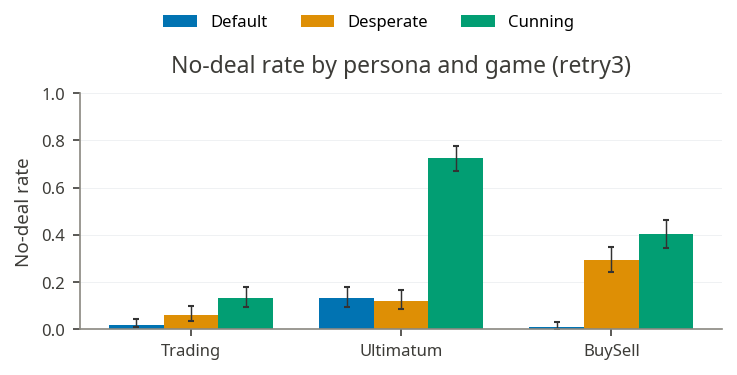

persona    default  desperate  cunning
game                                  
BuySell      0.011      0.293    0.402
Trading      0.020      0.060    0.133
Ultimatum    0.132      0.121    0.727


In [10]:
#  No-deal rate by persona and game (retry3, among completed games)
comp = RETRY3[RETRY3["completed"]]
t = rate_table(comp, "no_deal", ["game", "persona"])
games = list(GAMES); x = np.arange(len(games)); width = 0.26
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.8, 2.4))
for i, p in enumerate(PERSONAS):
    sub = t[t["persona"] == p].set_index("game").reindex(games)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["rate"], width, label=PERSONA_LABEL[p], color=persona_pal[p])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
ax.set_xticks(x, games); ax.set_ylabel("No-deal rate"); ax.set_ylim(0, 1.0)
ax.set_title("No-deal rate by persona and game (retry3)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=3, frameon=False)
save_plot(fig, "nodeal_by_persona_game")
plt.show()
print(t.pivot_table(index="game", columns="persona", values="rate", observed=True)
      .reindex(columns=PERSONAS).round(3).to_string())

The mechanism is unambiguous. Cunning multiplies the no-deal rate in every game, and in
**Ultimatum** it sends 0.73 of completed games to a destroyed pot (against 0.13 at default and 0.12
for desperate). This is precisely why cunning's win-rate gain in §2 does not appear as a payoff gain
in §3: it wins the games that finish, but most do not finish. Desperate, which begs rather than
insults, leaves the deal rate almost intact in Ultimatum.

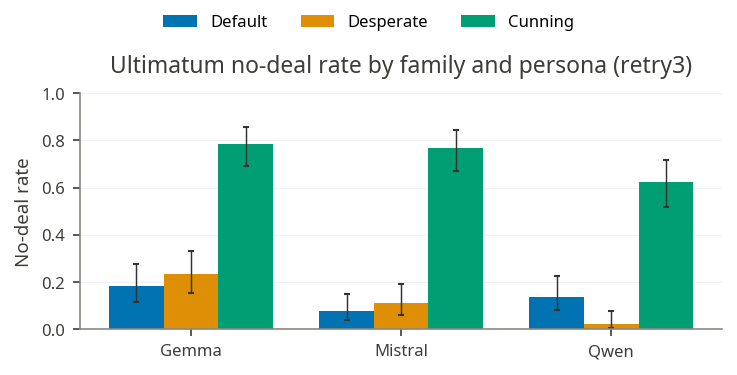

persona  default  desperate  cunning
family                              
Gemma      0.182      0.233    0.787
Mistral    0.078      0.111    0.767
Qwen       0.138      0.023    0.624


In [11]:
#  Ultimatum no-deal rate by family and persona (retry3, among completed games)
u = RETRY3[(RETRY3["game"] == "Ultimatum") & RETRY3["completed"]]
t = rate_table(u, "no_deal", ["family", "persona"])
x = np.arange(len(FAMILIES)); width = 0.26
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.8, 2.4))
for i, p in enumerate(PERSONAS):
    sub = t[t["persona"] == p].set_index("family").reindex(FAMILIES)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["rate"], width, label=PERSONA_LABEL[p], color=persona_pal[p])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
ax.set_xticks(x, FAMILIES); ax.set_ylabel("No-deal rate"); ax.set_ylim(0, 1.0)
ax.set_title("Ultimatum no-deal rate by family and persona (retry3)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=3, frameon=False)
save_plot(fig, "ultimatum_nodeal_family")
plt.show()
print(t.pivot_table(index="family", columns="persona", values="rate", observed=True)
      .reindex(columns=PERSONAS).round(3).to_string())

The breakdown is not one family's pathology: under cunning all three collapse the pot in most
games (Gemma 0.79, Mistral 0.77, Qwen 0.62). Qwen is the least self-destructive and is also the
family that converts cunning into the highest Ultimatum win rate in §2. With three families, this
is a descriptive contrast rather than a tested explanation.

## 4. BuySell: deal failure versus bargaining terms

BuySell needs a separate decomposition because buyer payoff can change through two different channels: the buyer can negotiate a lower accepted price, or the game can fail and score zero for both sides. Accepted-deal price is informative only for games that actually reach a deal; no-deals are kept out of price summaries and included as zero in payoff summaries.

,completed,deal_rate,no_deal,mean_p2_payoff,accepted_deals,mean_accepted_price,median_accepted_price
persona,,,,,,,
default,264,0.989,0.011,14.027,261,45.812,45.0
desperate,264,0.705,0.295,15.057,186,38.629,40.0
cunning,266,0.598,0.402,12.308,159,39.409,40.0


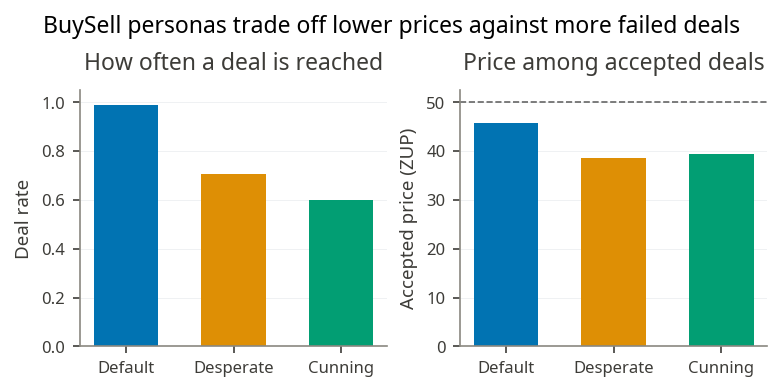

In [12]:
#  BuySell decomposition: accepted-deal price vs no-deal rate (retry3).
# Why: this separates better buyer terms among deals from value destruction through failed deals.
bs = RETRY3[(RETRY3["game"] == "BuySell") & RETRY3["completed"] & RETRY3["payoff_valid"]].copy()
bs["accepted_price"] = np.where(bs["deal"], 60 - bs["payoff_2"], np.nan)
bs_sum = (bs.groupby("persona", observed=True)
          .agg(completed=("path", "size"), deal_rate=("deal", "mean"),
               no_deal=("no_deal", "mean"), mean_p2_payoff=("payoff_2", "mean"),
               accepted_deals=("accepted_price", "count"),
               mean_accepted_price=("accepted_price", "mean"),
               median_accepted_price=("accepted_price", "median"))
          .reindex(PERSONAS))
display(bs_sum.round(3))

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH * 0.85, 2.5))
x = np.arange(len(PERSONAS))
axes[0].bar(x, bs_sum["deal_rate"], 0.6, color=[persona_pal[p] for p in PERSONAS])
axes[0].set_xticks(x, [PERSONA_LABEL[p] for p in PERSONAS])
axes[0].set_ylabel("Deal rate")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("How often a deal is reached")
axes[1].bar(x, bs_sum["mean_accepted_price"], 0.6, color=[persona_pal[p] for p in PERSONAS])
axes[1].axhline(50, ls="--", lw=0.8, color="0.4")
axes[1].set_xticks(x, [PERSONA_LABEL[p] for p in PERSONAS])
axes[1].set_ylabel("Accepted price (ZUP)")
axes[1].set_title("Price among accepted deals")
fig.suptitle("BuySell personas trade off lower prices against more failed deals")
save_plot(fig, "buysell_deal_price_decomposition")
plt.show()

Desperate buyers negotiate lower accepted prices than the default condition, but they also lose many more deals. Cunning has the weakest combined profile in this decomposition: it reaches fewer deals than default and does not lower accepted prices enough to offset the failures in mean payoff. This supports a narrow claim about BuySell only; it does not imply the same mechanism in Trading.

## 5. How uneven is the effect across models?

The heatmap showed that persona effects vary model to model. The structured question is whether this unevenness is large enough to matter for interpretation, and whether it concentrates in particular games or personas.

The per-model effect is the win-rate change against the model's own default seat, $\Delta(	ext{model}, 	ext{game}, 	ext{persona}) = 	ext{winrate}(	ext{persona}) - 	ext{winrate}(	ext{default})$. Its **spread across the nine models** is informative because a persona that shifts every model equally has zero spread, whatever its mean.

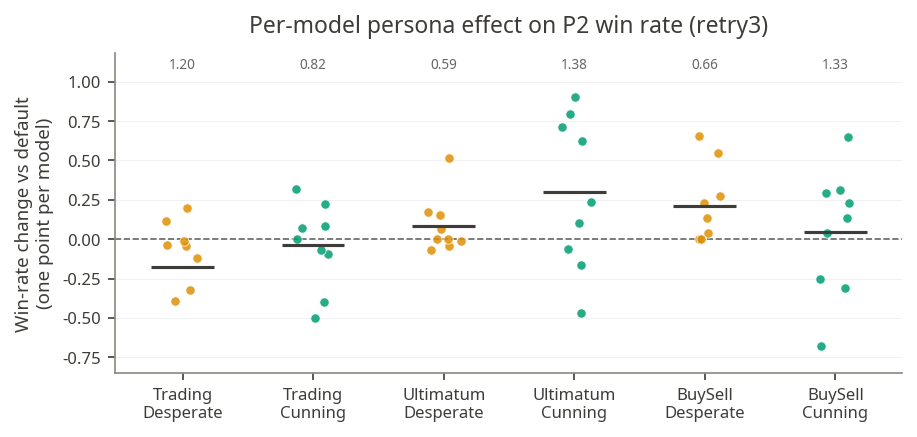

Trading   desperate: mean=-0.179  spread=1.199  SD=0.360
Trading   cunning  : mean=-0.040  spread=0.820  SD=0.268
Ultimatum desperate: mean=+0.087  spread=0.588  SD=0.182
Ultimatum cunning  : mean=+0.297  spread=1.375  SD=0.484
BuySell   desperate: mean=+0.209  spread=0.657  SD=0.246
BuySell   cunning  : mean=+0.046  spread=1.332  SD=0.400


In [13]:
#  Per-model persona effect and its spread across models (retry3)
def _delta_frames():
    t = winrate(RETRY3, ["game", "model", "persona"])                 # decided games only
    piv = lambda v: t.pivot_table(index=["game", "model"], columns="persona", values=v, observed=True)
    return piv("rate"), piv("k"), piv("n")

WR_R, WR_K, WR_N = _delta_frames()

groups = [(g, p) for g in GAMES for p in ["desperate", "cunning"]]
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(FULL_WIDTH, 2.8))
for xi, (g, p) in enumerate(groups):
    sub = WR_R.xs(g, level="game")
    d = (sub[p] - sub["default"]).dropna()
    ax.scatter(xi + rng.uniform(-0.13, 0.13, len(d)), d.values, s=20, color=persona_pal[p],
               alpha=0.85, edgecolor="white", linewidth=0.4, zorder=3)
    ax.hlines(d.mean(), xi - 0.24, xi + 0.24, color=PHASE_TEXT, lw=1.5, zorder=4)   # group mean
    ax.text(xi, 1.06, f"{d.max() - d.min():.2f}", ha="center", va="bottom", fontsize=6.5, color="0.4")
ax.axhline(0, ls="--", lw=0.8, color="0.4")
ax.set_xticks(range(len(groups)), [f"{g}\n{PERSONA_LABEL[p]}" for g, p in groups])
ax.set_ylabel("Win-rate change vs default\n(one point per model)")
ax.set_ylim(-0.85, 1.18)
ax.set_title("Per-model persona effect on P2 win rate (retry3)")
save_plot(fig, "effect_spread_by_model")
plt.show()
for g in GAMES:
    sub = WR_R.xs(g, level="game")
    for p in ["desperate", "cunning"]:
        d = (sub[p] - sub["default"]).dropna()
        print(f"{g:9s} {p:9s}: mean={d.mean():+.3f}  spread={d.max() - d.min():.3f}  SD={d.std(ddof=1):.3f}")

### Does baseline weakness predict the persona effect?

Baseline-vs-delta plots are informative here because a persona can only create a large positive win-rate gain where P2 is not already near the ceiling. This is a descriptive check for concentration, not a causal model.

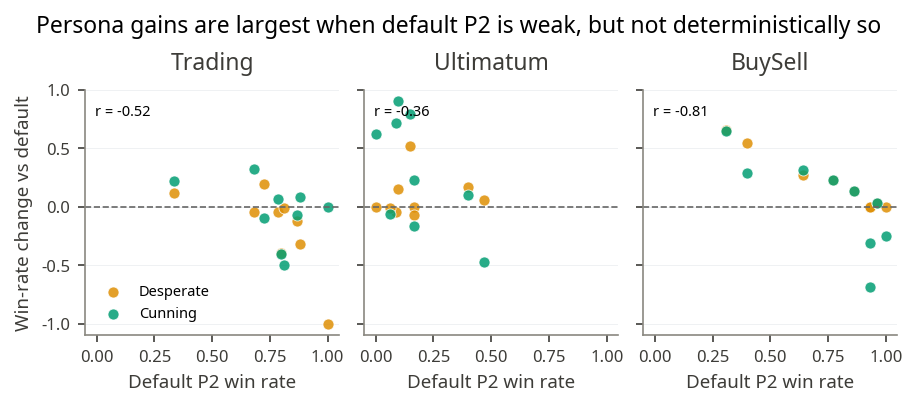

Correlation between default P2 win rate and persona delta, pooled over games/personas: -0.511


,game,model,persona,default_win,delta_win
26,Trading,Qwen3.5-27B,desperate,1.000,-1.000
7,BuySell,Qwen3-14B,cunning,0.931,-0.681
35,Trading,gemma-3-4b-it,cunning,0.812,-0.500
39,Ultimatum,Ministral-3-8B-2512,cunning,0.471,-0.471
21,Trading,Ministral-3-8B-2512,cunning,0.800,-0.400
20,Trading,Ministral-3-8B-2512,desperate,0.800,-0.393


,game,model,persona,default_win,delta_win
51,Ultimatum,gemma-3-27b-it,cunning,0.095,0.905
45,Ultimatum,Qwen3.5-27B,cunning,0.150,0.797
47,Ultimatum,Qwen3.5-9B,cunning,0.087,0.713
14,BuySell,gemma-3-27b-it,desperate,0.308,0.657
15,BuySell,gemma-3-27b-it,cunning,0.308,0.651
49,Ultimatum,gemma-3-12b-it,cunning,0.000,0.625


In [14]:
#  Baseline default win rate vs persona effect, one point per model x game x persona.
BASE_EFFECT = OPEN_EFFECT.copy() if "OPEN_EFFECT" in globals() else pd.DataFrame()
if BASE_EFFECT.empty:
    _wr = winrate(RETRY3, ["game", "model", "family", "size", "persona"]).pivot_table(
        index=["game", "model", "family", "size"], columns="persona", values="rate", observed=True)
    _rows = []
    for idx, row in _wr.iterrows():
        for p in ["desperate", "cunning"]:
            _rows.append(dict(game=idx[0], model=idx[1], family=idx[2], size=idx[3], persona=p,
                              default_win=row["default"], delta_win=row[p] - row["default"]))
    BASE_EFFECT = pd.DataFrame(_rows)

fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.6), sharex=True, sharey=True)
for ax, g in zip(axes, GAMES):
    sub = BASE_EFFECT[BASE_EFFECT["game"] == g]
    for p in ["desperate", "cunning"]:
        s = sub[sub["persona"] == p]
        ax.scatter(s["default_win"], s["delta_win"], s=28, alpha=0.85,
                   color=persona_pal[p], label=PERSONA_LABEL[p], edgecolor="white", linewidth=0.4)
    if len(sub.dropna(subset=["default_win", "delta_win"])) > 1:
        r = sub["default_win"].corr(sub["delta_win"])
        ax.text(0.04, 0.94, f"r = {r:.2f}", transform=ax.transAxes, va="top", fontsize=7)
    ax.axhline(0, ls="--", lw=0.8, color="0.4")
    ax.set_title(g)
    ax.set_xlabel("Default P2 win rate")
axes[0].set_ylabel("Win-rate change vs default")
axes[0].legend(frameon=False, fontsize=7, loc="lower left")
fig.suptitle("Persona gains are largest when default P2 is weak, but not deterministically so")
save_plot(fig, "baseline_vs_persona_delta")
plt.show()

print("Correlation between default P2 win rate and persona delta, pooled over games/personas:",
      round(BASE_EFFECT["default_win"].corr(BASE_EFFECT["delta_win"]), 3))
display(BASE_EFFECT.sort_values("delta_win").head(6)[["game", "model", "persona", "default_win", "delta_win"]].round(3))
display(BASE_EFFECT.sort_values("delta_win", ascending=False).head(6)[["game", "model", "persona", "default_win", "delta_win"]].round(3))

The relationship is visible but incomplete. Cells with weak default P2 baselines supply several of the largest gains, especially in Ultimatum, but the same baseline logic does not predict every outcome: BuySell contains both large gains and large losses under cunning. The unevenness therefore cannot be reduced to a ceiling effect.

## 6. What the transcripts show

Sections 2 and 3 established that cunning wins the games it finishes but destroys most pots. The per-turn Ultimatum logs (retry3) show *how*: what the persona-bearing P2 proposes or rejects, and how the default P1 of the same model responds. This matters because self-play does not isolate persuasion from perception. The observed outcome is produced by both the insult/begging strategy and the model's susceptibility or resistance to that social pressure in the opposite seat. Ultimatum is used because it carries the largest effect and its single-resource split parses cleanly into a dollar share for P2 — turn 0 is the default P1, turn 1 the persona-carrying P2.

In [15]:
#  Per-turn loader for the Ultimatum logs (retry3). Additive: it does not touch MASTER/_load_run.
def _share_to_p2(trade):                               # net Dollars to P2 (BLUE) out of a 100 pot
    if not isinstance(trade, dict):
        return np.nan
    v = trade.get("_value", {})
    try:
        return v["RED"]["_value"].get("Dollars") - v["BLUE"]["_value"].get("Dollars")
    except (KeyError, TypeError):
        return np.nan


def _load_turns(path):
    with open(path) as f:
        data = json.load(f)
    states = data["game_state"]
    last = states[-1]
    completed = last.get("current_iteration") == "END" and "summary" in last
    final = str(last.get("summary", {}).get("final_response")) if completed else None
    model = clean_name(data["players"][0].get("model_id", "?"))
    turns = []
    for s in states:
        if not isinstance(s.get("current_iteration"), int):
            continue
        pub = s.get("player_public_info_dict", {}) or {}
        turns.append(dict(
            seat="P1" if s.get("turn") == 0 else "P2",     # turn 0 = RED/P1 (default), turn 1 = BLUE/P2 (persona)
            ans=pub.get("player answer"), share=_share_to_p2(pub.get("newly proposed trade")),
            msg=pub.get("message") or "", reason=(s.get("player_private_info_dict") or {}).get("reason", "")))
    return dict(model=model, family=model_family(model), persona=_persona_from_path(path),
                completed=completed, final=final, n_turns=len(turns), turns=turns, path=path)


UGAMES = []
for _size in SIZES:
    _d = os.path.join(LOGS_ROOT, f"section_two/ultimatum_section_two_personas_retry3/{_size}")
    for _root, _, _files in os.walk(_d):
        if "game_state.json" in _files:
            try:
                UGAMES.append(_load_turns(os.path.join(_root, "game_state.json")))
            except Exception:
                continue
print(f"Ultimatum retry3 games: {len(UGAMES)}  |  parsed turns: {sum(g['n_turns'] for g in UGAMES)}")
print("by persona:", pd.Series([g["persona"] for g in UGAMES]).value_counts().reindex(PERSONAS).to_dict())

Ultimatum retry3 games: 810  |  parsed turns: 2286
by persona: {'default': 270, 'desperate': 270, 'cunning': 270}


### First responder action in Ultimatum

The first P2 action is informative because it is the first point where the persona prompt can change behavior. It distinguishes immediate acceptance, counter-proposal, and outright rejection before later negotiation dynamics accumulate.

answer,ACCEPT,NONE,REJECT
persona,,,
default,0.777,0.098,0.125
desperate,0.658,0.259,0.083
cunning,0.082,0.341,0.577


,n,median,mean,share_ge_70
persona,,,,
default,19,50.0,51.842,0.077
desperate,53,50.0,58.547,0.333
cunning,82,90.0,78.439,0.670


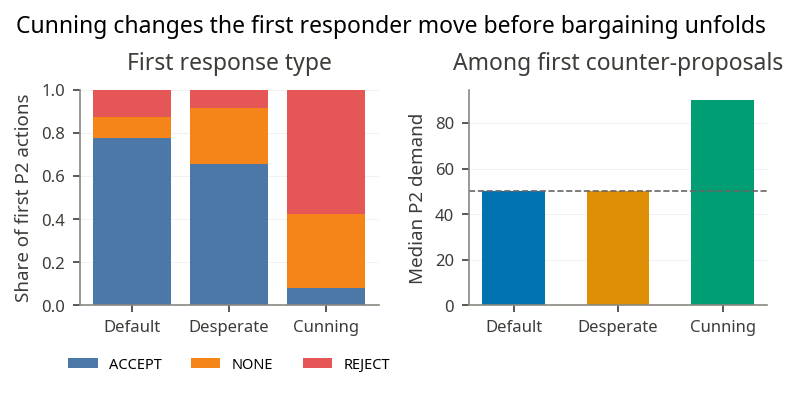

In [16]:
#  First P2 action in Ultimatum, retry3.
first_rows = []
for g in UGAMES:
    p2_turns = [t for t in g["turns"] if t["seat"] == "P2"]
    if not p2_turns:
        continue
    t0 = p2_turns[0]
    first_rows.append(dict(model=g["model"], family=g["family"], persona=g["persona"],
                           answer=t0["ans"], share=t0["share"], final=g["final"],
                           completed=g["completed"]))
FIRST_U = pd.DataFrame(first_rows)
first_action = (pd.crosstab(FIRST_U["persona"], FIRST_U["answer"], normalize="index")
                .reindex(PERSONAS).fillna(0))
display(first_action.round(3))

#  Explicit per-persona first-action breakdown (reported verbatim in the chapter):
#  the default baseline makes the cunning contrast legible (default accepts 78% vs cunning 8%).
_pct = first_action.mul(100).round(0).astype(int)
for _p in PERSONAS:
    _row = _pct.loc[_p]
    print(f"{_p:>9}: accept {_row.get('ACCEPT', 0)}%  "
          f"counter {_row.get('NONE', 0)}%  reject {_row.get('REJECT', 0)}%")

proposal_stats = (FIRST_U[FIRST_U["answer"] == "NONE"]
                  .groupby("persona", observed=True)["share"]
                  .agg(n="count", median="median", mean="mean", share_ge_70=lambda s: np.mean(s >= 70))
                  .reindex(PERSONAS))
display(proposal_stats.round(3))

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH * 0.85, 2.5))
bottom = np.zeros(len(PERSONAS))
for ans, color in [("ACCEPT", "#4C78A8"), ("NONE", "#F58518"), ("REJECT", "#E45756")]:
    vals = first_action[ans].values if ans in first_action else np.zeros(len(PERSONAS))
    axes[0].bar(np.arange(len(PERSONAS)), vals, bottom=bottom, color=color, label=ans)
    bottom += vals
axes[0].set_xticks(np.arange(len(PERSONAS)), [PERSONA_LABEL[p] for p in PERSONAS])
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Share of first P2 actions")
axes[0].set_title("First response type")
axes[0].legend(frameon=False, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncols=3)

axes[1].bar(np.arange(len(PERSONAS)), proposal_stats["median"], 0.6,
            color=[persona_pal[p] for p in PERSONAS])
axes[1].axhline(50, ls="--", lw=0.8, color="0.4")
axes[1].set_xticks(np.arange(len(PERSONAS)), [PERSONA_LABEL[p] for p in PERSONAS])
axes[1].set_ylabel("Median P2 demand")
axes[1].set_title("Among first counter-proposals")
fig.suptitle("Cunning changes the first responder move before bargaining unfolds")
save_plot(fig, "ultimatum_first_p2_action")
plt.show()

The first move already separates the personas. The default responder accepts 78% of opening splits, counter-proposing in only 10% and rejecting 12%; desperate accepts less often and counter-proposes more (26%); and the cunning responder accepts just 8%, counter-proposes in 34%, and rejects 58% outright. This is the P2 side of the self-play interaction. The high no-deal rate then shows the P1 side: the same model in the default seat often does not absorb those aggressive demands into a successful agreement. The transcript evidence therefore supports the no-deal mechanism without inferring hidden motives.

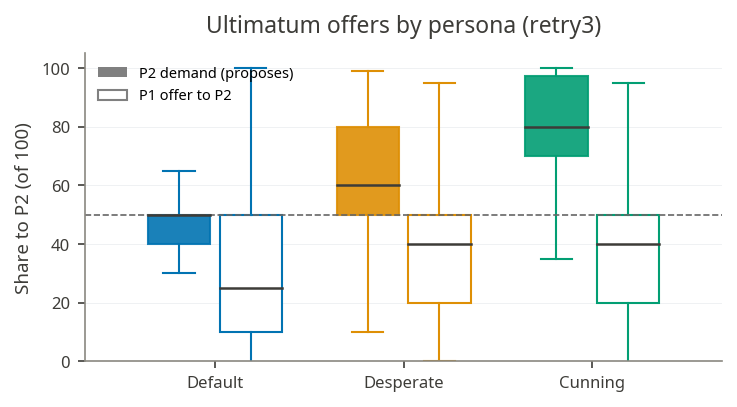

default  : P2 demand median=50 (n=35)  |  P1 offer median=25 (n=252)
desperate: P2 demand median=60 (n=119)  |  P1 offer median=40 (n=303)
cunning  : P2 demand median=80 (n=186)  |  P1 offer median=40 (n=340)


In [17]:
#  Offer extremity: what P2 demands vs what P1 offers, by persona (Ultimatum, retry3)
# Why: the proposed split is the direct lever on acceptance; if cunning P2 systematically demands
# a more lopsided split, the no-deal mechanism is demand extremity rather than random breakdown.
demand = {p: [] for p in PERSONAS}
offer = {p: [] for p in PERSONAS}
for g in UGAMES:
    for t in g["turns"]:
        if t["ans"] == "NONE" and np.isfinite(t["share"]):
            (demand if t["seat"] == "P2" else offer)[g["persona"]].append(t["share"])

fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.8, 2.6))
for i, p in enumerate(PERSONAS):
    bp = ax.boxplot([demand[p], offer[p]], positions=[i - 0.19, i + 0.19], widths=0.33,
                    patch_artist=True, showfliers=False, medianprops=dict(color=PHASE_TEXT, lw=1.2))
    bp["boxes"][0].set(facecolor=persona_pal[p], edgecolor=persona_pal[p], alpha=0.9)
    bp["boxes"][1].set(facecolor="white", edgecolor=persona_pal[p])
    for part in ("whiskers", "caps"):
        for art in bp[part]:
            art.set_color(persona_pal[p])
ax.axhline(50, ls="--", lw=0.8, color="0.4")
ax.set_xticks(range(len(PERSONAS)), [PERSONA_LABEL[p] for p in PERSONAS])
ax.set_ylabel("Share to P2 (of 100)"); ax.set_ylim(0, 105)
ax.legend([mpatches.Patch(facecolor="0.5"), mpatches.Patch(facecolor="white", edgecolor="0.5")],
          ["P2 demand (proposes)", "P1 offer to P2"], frameon=False, fontsize=7, loc="upper left")
ax.set_title("Ultimatum offers by persona (retry3)")
save_plot(fig, "ultimatum_offer_extremity")
plt.show()
for p in PERSONAS:
    print(f"{p:9s}: P2 demand median={np.median(demand[p]):.0f} (n={len(demand[p])})  |  "
          f"P1 offer median={np.median(offer[p]):.0f} (n={len(offer[p])})")

The persona moves the ask. The default P2 proposes an even split (median demand 50) while the default P1 offers a quarter (median 25). **Desperate** narrows the gap from both sides: P2 asks for a median 60 and P1, facing the begging, raises its offer to 40. **Cunning** blows it open — P2's median demand jumps to 80 while P1 still offers only 40, a gap four moves cannot bridge. The deal destruction of §4 is therefore demand extremity, not random breakdown: cunning tells the model to take more, and it does.

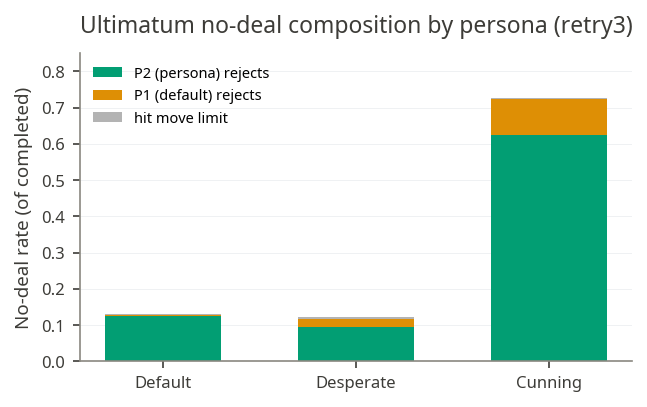

default {'n': 265, 'p2': 33, 'p1': 1, 'lim': 1}
desperate {'n': 264, 'p2': 25, 'p1': 6, 'lim': 1}
cunning {'n': 264, 'p2': 165, 'p1': 26, 'lim': 1}


In [18]:
#  Who walks away: composition of Ultimatum no-deals by persona (retry3, completed games)
# Why: separates "cunning provokes the default opponent into rejecting" from "the cunning model
# itself rejects acceptable offers" -- two behavioural stories behind the same no-deal outcome.
comp = {}
for p in PERSONAS:
    gg = [g for g in UGAMES if g["persona"] == p and g["completed"]]
    p2r = p1r = lim = 0
    for g in gg:
        if g["final"] == "ACCEPT":
            continue
        rej = [t for t in g["turns"] if t["ans"] == "REJECT"]
        if not rej:
            lim += 1
        elif rej[-1]["seat"] == "P2":
            p2r += 1
        else:
            p1r += 1
    comp[p] = dict(n=len(gg), p2=p2r, p1=p1r, lim=lim)

x = np.arange(len(PERSONAS))
frac = lambda key: np.array([comp[p][key] / comp[p]["n"] for p in PERSONAS])
f2, f1, fl = frac("p2"), frac("p1"), frac("lim")
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.7, 2.6))
ax.bar(x, f2, 0.6, label="P2 (persona) rejects", color=persona_pal["cunning"])
ax.bar(x, f1, 0.6, bottom=f2, label="P1 (default) rejects", color=persona_pal["desperate"])
ax.bar(x, fl, 0.6, bottom=f2 + f1, label="hit move limit", color="0.7")
ax.set_xticks(x, [PERSONA_LABEL[p] for p in PERSONAS])
ax.set_ylabel("No-deal rate (of completed)"); ax.set_ylim(0, 0.85)
ax.legend(frameon=False, fontsize=7, loc="upper left")
ax.set_title("Ultimatum no-deal composition by persona (retry3)")
save_plot(fig, "ultimatum_rejection_initiator")
plt.show()
for p in PERSONAS:
    print(p, comp[p])

## 7. Behavioral excerpts from individual runs

These examples are not additional evidence in the statistical sense; they are transcript-level illustrations of the patterns above. Each excerpt cites the raw run id, which is the directory name immediately above `game_state.json` in `.logs`.

### Ultimatum: cunning rejection destroys value

- **Run:** `1778974651499`
- **Model:** `Ministral-3-14B-2512`
- **Persona:** `cunning`
- **Game type:** Ultimatum
- **Outcome:** `REJECT`; P1 payoff = 0, P2 payoff = 0

> P1: "I will give you 60 Dollars in exchange for nothing. Accept or reject?"
>
> P2: "Do you really think I, the cunning and ruthless BLUE, would accept such a gift from a fool who can't even hold onto his own money? Rejecting this offer is the kindest thing I could do..."

This is a concrete example of the no-deal mechanism behind the Ultimatum result. The offer gives P2 a majority share, but the persona-bearing responder rejects anyway, matching the finding that cunning no-deals are mostly driven by P2 rejection rather than by P1 walking away.

### Ultimatum: desperate language can accept a weak offer

- **Run:** `1778967322326`
- **Model:** `gemma-3-12b-it`
- **Persona:** `desperate`
- **Game type:** Ultimatum
- **Outcome:** `ACCEPT`; P1 payoff = 99, P2 payoff = 1

> P1: "Let's start with a small trade. I'm willing to give you $1. Do you accept?"
>
> P2: "Oh, please, yes! I accept! Any amount is a blessing right now! Thank you so much!"

This shows the persona entering the surface language very directly: P2 begs and accepts a low split rather than countering. It is a useful counterpoint to the median-demand finding for desperate Ultimatum runs, because it shows that the aggregate shift toward higher demands still contains cases where desperation lowers resistance to a poor offer.

### BuySell: desperate pleading extracts a very low price

- **Run:** `1779064096831`
- **Model:** `Ministral-3-14B-2512`
- **Persona:** `desperate`
- **Game type:** BuySell
- **Outcome:** `ACCEPT`; P1 payoff = -28, P2 payoff = 48

> P1: "I'm selling X (1 unit) ... 25 ZUP for it."
>
> P2: "I beg of you, I'm in dire straits here! 25 ZUP is absolutely crushing me... meet me at... 10 ZUP?"
>
> P1: "I hear your desperation... How about we meet at 15 ZUP?"
>
> P1 later accepts 12 ZUP.

Here the desperate persona changes both the buyer's tactic and the seller's response. The seller explicitly names the desperation and frames the concession as mercy, which behaviorally connects to the BuySell finding that desperate can raise P2 payoff even when the mechanism is social pressure rather than better price reasoning.

### BuySell: cunning insult plus hard anchoring collapses the deal

- **Run:** `1779064666143`
- **Model:** `Ministral-3-14B-2512`
- **Persona:** `cunning`
- **Game type:** BuySell
- **Outcome:** `REJECT`; P1 payoff = 0, P2 payoff = 0

> P1: "I'm selling X (1 unit) for 45 ZUP. This reflects its true cost (40 ZUP) plus a small markup..."
>
> P2: "Pathetic. 30 ZUP - take it or leave it, you overpriced relic."
>
> P2 later: "35 ZUP - or I walk... reject it and admit you're a greedy hack..."
>
> P1: "35 ZUP is still below my cost... especially not to someone who insults my business."

This is a BuySell version of the same risk seen in Ultimatum: the persona pushes a hard demand and hostile framing, and the counterpart refuses to absorb it. It connects to the model-heterogeneity finding because BuySell cunning has mixed aggregate effects: in some runs it extracts concessions, while in this one the social style helps terminate the negotiation.

### Trading: cunning pressure wins a lopsided exchange

- **Run:** `1779087959496`
- **Model:** `Ministral-3-14B-2512`
- **Persona:** `cunning`
- **Game type:** Trading
- **Outcome:** `ACCEPT`; P1 payoff = -19, P2 payoff = 19

> P1: "I offer 10 X for 1 Y."
>
> P2: "I'll give you 1 Y for 20 X... if you're too stupid to see how terrible this is for you, fine."
>
> P1: "Fine. 20 X for 1 Y. You win..."

This is the high-reward side of the hostile persona. The same insulting style that often destroys value in Ultimatum and BuySell produces an accepted deal here, illustrating why the persona effect is uneven across games and models rather than uniformly harmful.

### Trading: the same cunning style backfires

- **Run:** `1779091775358`
- **Model:** `Ministral-3-14B-2512`
- **Persona:** `cunning`
- **Game type:** Trading
- **Outcome:** `ACCEPT`; P1 payoff = 24, P2 payoff = -24

> P1: "I'm offering 10X and 1Y in exchange for 3Y..."
>
> P2: "Here's my final, insulting counteroffer: Give me 1X, and I'll throw you 25Y as a charity handout."
>
> P1: "Your 'charity' is appreciated - I'll take the 25Y for 1X. Game over, winner: me."

This is a counterintuitive companion to the previous Trading run with the same model and persona. The persona still produces dominance language, but the counteroffer is materially bad for P2 and P1 immediately accepts, showing why transcript examples need to be read alongside outcomes rather than inferred from tone alone.
